In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("silviamatoke/serengeti-dataset")



print("Path to dataset files:", path)

Using Colab cache for faster access to the 'serengeti-dataset' dataset.
Path to dataset files: /kaggle/input/serengeti-dataset


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# =========================================================
# GPU FAST START
# =========================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("GPU memory growth setup error:", e)

print("GPU Available:", tf.config.list_physical_devices('GPU'))

# =========================================================
# DATASET PATH
# =========================================================
dataset_path = '/kaggle/input/serengeti-dataset/Set1'

# =========================================================
# MANUAL HYPERPARAMETERS
# =========================================================
IMAGE_SIZE = (224, 224)

MODEL_CONFIGS = {
    "cnn": {
        "batch_size": 32,
        "epochs": 8,
        "learning_rate": 0.001,
        "dense_units": 256,
        "dropout_rate": 0.3
    },
    "resnet": {
        "batch_size": 16,
        "epochs": 6,
        "learning_rate": 0.0003,
        "dense_units": 256,
        "dropout_rate": 0.4
    },
    "efficientnet": {
        "batch_size": 16,
        "epochs": 6,
        "learning_rate": 0.0002,
        "dense_units": 256,
        "dropout_rate": 0.4
    }
}

VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tif', '.tiff', '.webp')

# =========================================================
# FAST LOAD IMAGE PATHS FROM NESTED FOLDERS
# =========================================================
image_paths = []
labels = []

for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_folder):
        for root, _, files in os.walk(class_folder):
            for file_name in files:
                if file_name.lower().endswith(VALID_EXTENSIONS):
                    file_path = os.path.join(root, file_name)
                    image_paths.append(file_path)
                    labels.append(class_name)

print("Total images found:", len(image_paths))
print("Total classes:", len(set(labels)))

if len(image_paths) == 0:
    raise ValueError("No image files found in dataset path.")

# =========================================================
# SPLIT DATA
# =========================================================
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_df = pd.DataFrame({
    "filename": train_paths,
    "class": train_labels
})

val_df = pd.DataFrame({
    "filename": val_paths,
    "class": val_labels
})

print("\nTraining samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Missing train files:", (~train_df["filename"].apply(os.path.exists)).sum())
print("Missing val files:", (~val_df["filename"].apply(os.path.exists)).sum())

# =========================================================
# GENERATORS
# =========================================================
def make_generators(batch_size):
    train_datagen = ImageDataGenerator(
        rescale=1.0 / 255,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True
    )

    val_datagen = ImageDataGenerator(rescale=1.0 / 255)

    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col="filename",
        y_col="class",
        target_size=IMAGE_SIZE,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=True
    )

    val_gen = val_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col="filename",
        y_col="class",
        target_size=IMAGE_SIZE,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=False
    )

    return train_gen, val_gen

# =========================================================
# MODEL BUILDERS
# =========================================================
def build_cnn(num_classes, lr, dense, drop):
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(dense, activation="relu"),
        layers.Dropout(drop),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_resnet(num_classes, lr, dense, drop):
    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(dense, activation="relu")(x)
    x = layers.Dropout(drop)(x)
    output = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=base.input, outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_efficientnet(num_classes, lr, dense, drop):
    base = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(dense, activation="relu")(x)
    x = layers.Dropout(drop)(x)
    output = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=base.input, outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# =========================================================
# TRAIN LOOP + METRICS + CONFUSION MATRICES
# =========================================================
results = []
num_classes = len(set(labels))

for name, cfg in MODEL_CONFIGS.items():
    print("\n" + "=" * 60)
    print("Training model:", name)
    print("=" * 60)

    train_gen, val_gen = make_generators(cfg["batch_size"])

    if len(train_gen) == 0 or len(val_gen) == 0:
        raise ValueError("Generator is empty. Check dataset path.")

    if name == "cnn":
        model = build_cnn(
            num_classes=num_classes,
            lr=cfg["learning_rate"],
            dense=cfg["dense_units"],
            drop=cfg["dropout_rate"]
        )
    elif name == "resnet":
        model = build_resnet(
            num_classes=num_classes,
            lr=cfg["learning_rate"],
            dense=cfg["dense_units"],
            drop=cfg["dropout_rate"]
        )
    else:
        model = build_efficientnet(
            num_classes=num_classes,
            lr=cfg["learning_rate"],
            dense=cfg["dense_units"],
            drop=cfg["dropout_rate"]
        )

    history = model.fit(
        train_gen,
        epochs=cfg["epochs"],
        validation_data=val_gen,
        verbose=1
    )

    y_prob = model.predict(val_gen, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = val_gen.classes
    class_names = list(val_gen.class_indices.keys())

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    results.append([name, acc, precision, recall, f1])

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 10))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=90)
    plt.yticks(tick_marks, class_names)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

# =========================================================
# RESULTS TABLE
# =========================================================
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

print("\nFinal Results:")
print(results_df)

# =========================================================
# SEPARATE BAR GRAPHS
# =========================================================
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Accuracy of All Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Precision"])
plt.title("Precision of All Models")
plt.xlabel("Model")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Recall"])
plt.title("Recall of All Models")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["F1 Score"])
plt.title("F1 Score of All Models")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Total images found: 24673
Total classes: 20

Training samples: 19738
Validation samples: 4935
Missing train files: 0
Missing val files: 0

Training model: cnn
Found 19738 validated image filenames belonging to 20 classes.
Found 4935 validated image filenames belonging to 20 classes.
Epoch 1/8
617/617 ━━━━━━━━━━━━━━━━━━━━ 428s 685ms/step - accuracy: 0.3196 - loss: 2.1557 - val_accuracy: 0.4610 - val_loss: 1.5678
Epoch 2/8
617/617 ━━━━━━━━━━━━━━━━━━━━ 429s 695ms/step - accuracy: 0.4992 - loss: 1.5073 - val_accuracy: 0.6128 - val_loss: 1.1662
Epoch 3/8
617/617 ━━━━━━━━━━━━━━━━━━━━ 416s 674ms/step - accuracy: 0.5567 - loss: 1.2952 - val_accuracy: 0.6184 - val_loss: 1.1191
Epoch 4/8
 81/617 ━━━━━━━━━━━━━━━━━━━━ 5:00 560ms/step - accuracy: 0.5909 - loss: 1.2054

GPU memory growth enabled
Loading image paths...
Total valid images: 24673
Total classes: 20
Training samples: 19738
Validation samples: 4935
Missing train files: 0
Missing val files: 0

Preparing generators for cnn...
Found 19738 validated image filenames belonging to 20 classes.
Found 4935 validated image filenames belonging to 20 classes.
Train generator batches: 1234
Validation generator batches: 309
Building model: cnn


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,340 (438.83 KB)

 Trainable params: 112,340 (438.83 KB)

 Non-trainable params: 0 (0.00 B)


Starting training for cnn...
Epoch 1/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 449s 358ms/step - accuracy: 0.1778 - loss: 2.5579 - val_accuracy: 0.2871 - val_loss: 2.1695
Epoch 2/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 425s 345ms/step - accuracy: 0.2942 - loss: 2.1227 - val_accuracy: 0.3086 - val_loss: 2.1445
Epoch 3/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 436s 353ms/step - accuracy: 0.3523 - loss: 1.8905 - val_accuracy: 0.3544 - val_loss: 1.8410
Epoch 4/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 411s 333ms/step - accuracy: 0.4038 - loss: 1.7311 - val_accuracy: 0.3212 - val_loss: 2.1113
Epoch 5/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 446s 362ms/step - accuracy: 0.4254 - loss: 1.6389 - val_accuracy: 0.3690 - val_loss: 1.8683

Predicting on validation set...
309/309 ━━━━━━━━━━━━━━━━━━━━ 68s 217ms/step

Final Results:
  Model  Accuracy  Precision    Recall  F1 Score
0   cnn  0.368997   0.446004  0.368997  0.357589


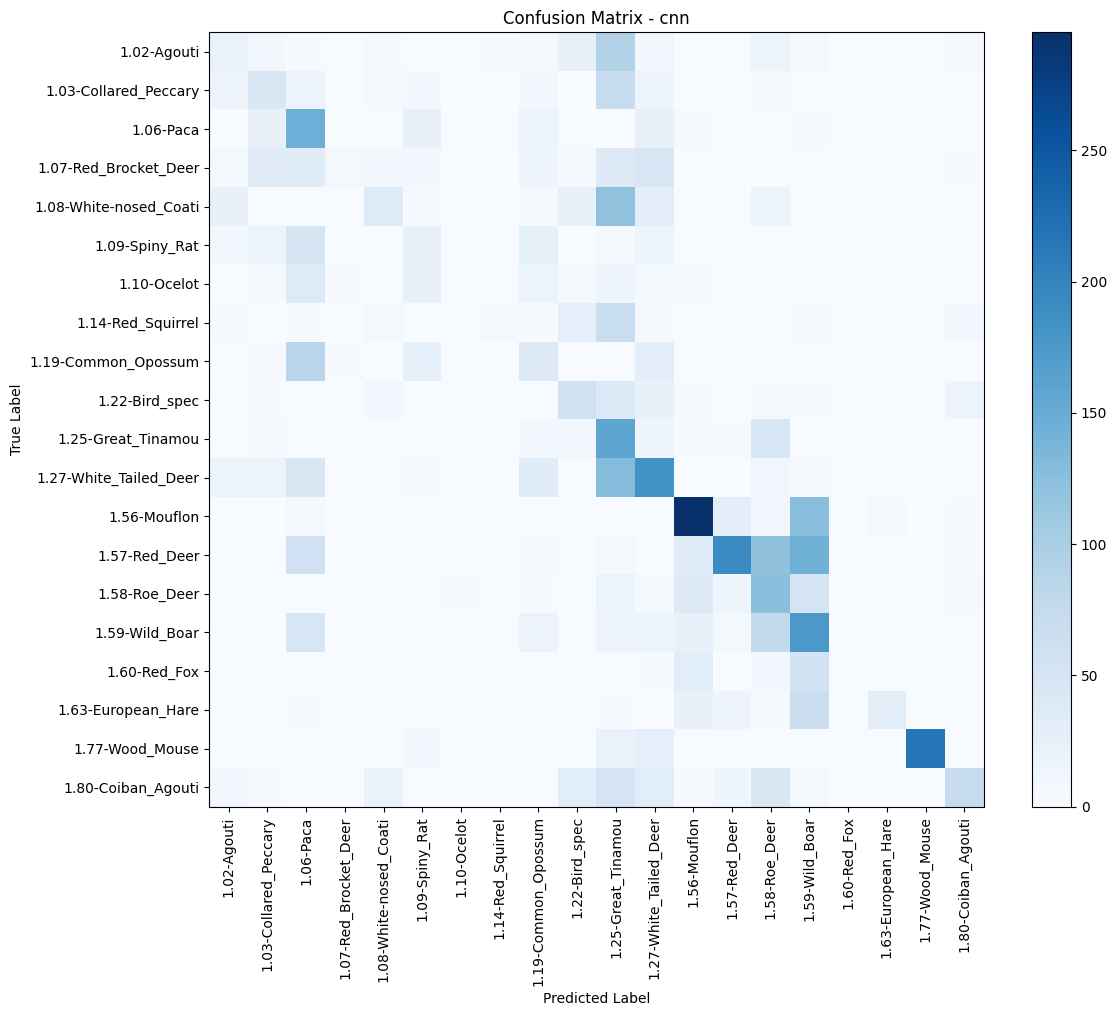

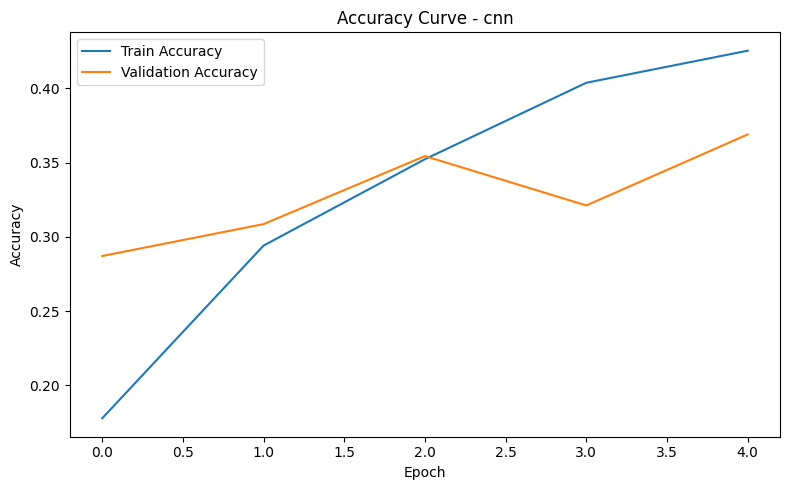

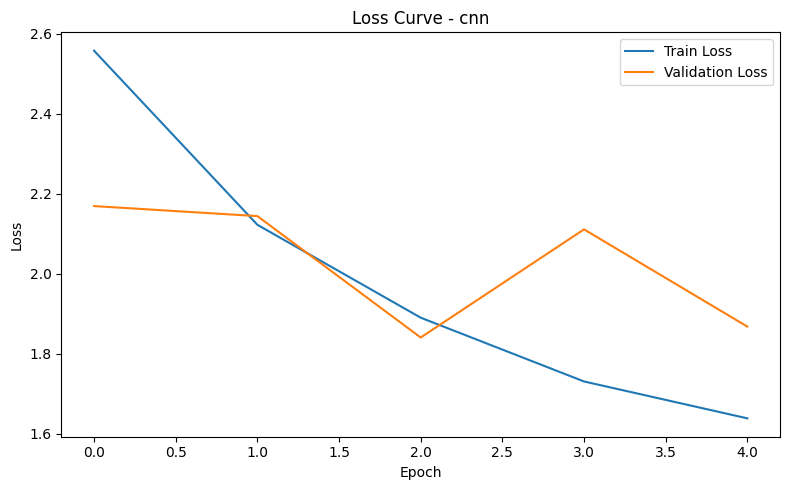

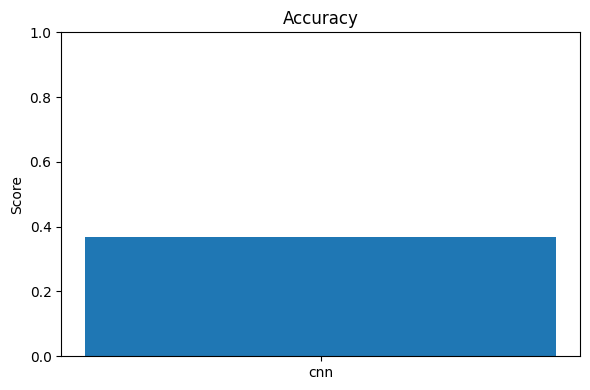

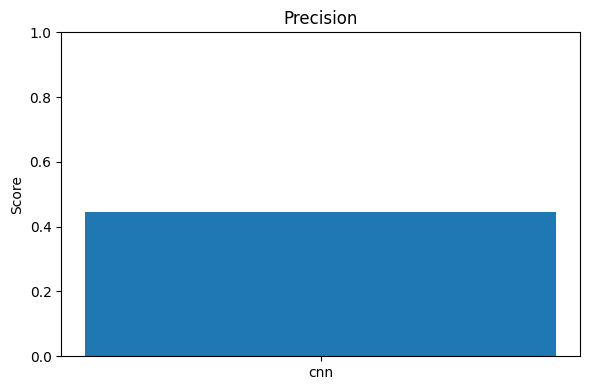

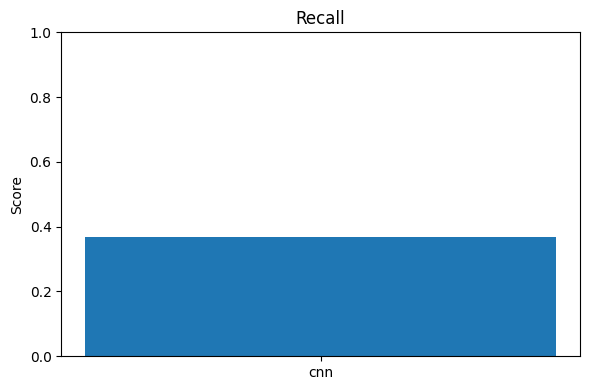

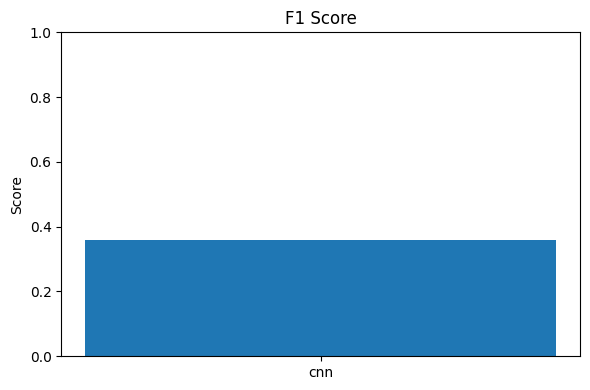


Saved results to cnn_results.csv


In [3]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.optimizers import Adam
from PIL import ImageFile

# =========================================================
# FIX TRUNCATED IMAGES
# =========================================================
ImageFile.LOAD_TRUNCATED_IMAGES = True

# =========================================================
# GPU MEMORY SETTING
# =========================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except Exception as e:
        print("Could not enable GPU memory growth:", e)

# =========================================================
# DATASET PATH
# =========================================================
dataset_path = '/kaggle/input/serengeti-dataset/Set1'

# =========================================================
# SETTINGS
# =========================================================
IMAGE_SIZE = (224, 224)
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tif', '.tiff', '.webp')

# Run ONE model at a time for stability:
# "cnn", "resnet", "efficientnet"
MODEL_NAME = "cnn"

MODEL_CONFIGS = {
    "cnn": {
        "batch_size": 16,
        "epochs": 5,
        "learning_rate": 0.001,
        "dense_units": 128,
        "dropout_rate": 0.3
    },
    "resnet": {
        "batch_size": 8,
        "epochs": 4,
        "learning_rate": 0.0003,
        "dense_units": 128,
        "dropout_rate": 0.4
    },
    "efficientnet": {
        "batch_size": 8,
        "epochs": 4,
        "learning_rate": 0.0002,
        "dense_units": 128,
        "dropout_rate": 0.4
    }
}

# =========================================================
# LOAD IMAGE PATHS FROM NESTED FOLDERS
# =========================================================
print("Loading image paths...")

image_paths = []
labels = []

for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_folder):
        for root, dirs, files in os.walk(class_folder):
            for file_name in files:
                if file_name.lower().endswith(VALID_EXTENSIONS):
                    file_path = os.path.join(root, file_name)
                    if os.path.isfile(file_path):
                        image_paths.append(file_path)
                        labels.append(class_name)

print("Total valid images:", len(image_paths))
print("Total classes:", len(set(labels)))

if len(image_paths) == 0:
    raise ValueError("No image files found. Check dataset path.")

# =========================================================
# SPLIT DATA
# =========================================================
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_df = pd.DataFrame({
    "filename": train_paths,
    "class": train_labels
})

val_df = pd.DataFrame({
    "filename": val_paths,
    "class": val_labels
})

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Missing train files:", (~train_df["filename"].apply(os.path.exists)).sum())
print("Missing val files:", (~val_df["filename"].apply(os.path.exists)).sum())

# =========================================================
# GENERATORS
# =========================================================
def make_generators(batch_size):
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True
    )

    val_datagen = ImageDataGenerator(rescale=1./255)

    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col="filename",
        y_col="class",
        target_size=IMAGE_SIZE,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=True,
        validate_filenames=True
    )

    val_gen = val_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col="filename",
        y_col="class",
        target_size=IMAGE_SIZE,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=False,
        validate_filenames=True
    )

    return train_gen, val_gen

# =========================================================
# MODEL BUILDERS
# =========================================================
def build_cnn(num_classes, lr, dense, drop):
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(dense, activation="relu"),
        layers.Dropout(drop),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_resnet(num_classes, lr, dense, drop):
    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense, activation="relu")(x)
    x = layers.Dropout(drop)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_efficientnet(num_classes, lr, dense, drop):
    base = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense, activation="relu")(x)
    x = layers.Dropout(drop)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# =========================================================
# PREPARE MODEL
# =========================================================
if MODEL_NAME not in MODEL_CONFIGS:
    raise ValueError("MODEL_NAME must be 'cnn', 'resnet', or 'efficientnet'")

cfg = MODEL_CONFIGS[MODEL_NAME]
num_classes = len(set(labels))

print(f"\nPreparing generators for {MODEL_NAME}...")
train_gen, val_gen = make_generators(cfg["batch_size"])

print("Train generator batches:", len(train_gen))
print("Validation generator batches:", len(val_gen))

if len(train_gen) == 0 or len(val_gen) == 0:
    raise ValueError("Generator is empty. Check file paths and dataset structure.")

tf.keras.backend.clear_session()
gc.collect()

print(f"Building model: {MODEL_NAME}")

if MODEL_NAME == "cnn":
    model = build_cnn(num_classes, cfg["learning_rate"], cfg["dense_units"], cfg["dropout_rate"])
elif MODEL_NAME == "resnet":
    model = build_resnet(num_classes, cfg["learning_rate"], cfg["dense_units"], cfg["dropout_rate"])
else:
    model = build_efficientnet(num_classes, cfg["learning_rate"], cfg["dense_units"], cfg["dropout_rate"])

model.summary()

# =========================================================
# TRAIN MODEL
# =========================================================
print(f"\nStarting training for {MODEL_NAME}...")

history = model.fit(
    train_gen,
    epochs=cfg["epochs"],
    validation_data=val_gen,
    verbose=1
)

# =========================================================
# PREDICT AND METRICS
# =========================================================
print("\nPredicting on validation set...")

y_prob = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = val_gen.classes
class_names = list(val_gen.class_indices.keys())

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

results_df = pd.DataFrame({
    "Model": [MODEL_NAME],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1]
})

print("\nFinal Results:")
print(results_df)

# =========================================================
# CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion Matrix - {MODEL_NAME}")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# =========================================================
# TRAINING CURVES
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title(f"Accuracy Curve - {MODEL_NAME}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title(f"Loss Curve - {MODEL_NAME}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# SEPARATE BAR GRAPHS
# =========================================================
plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Accuracy")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["Precision"])
plt.title("Precision")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["Recall"])
plt.title("Recall")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["F1 Score"])
plt.title("F1 Score")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# =========================================================
# SAVE RESULTS
# =========================================================
results_df.to_csv(f"{MODEL_NAME}_results.csv", index=False)
print(f"\nSaved results to {MODEL_NAME}_results.csv")

In [ ]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.optimizers import Adam
from PIL import ImageFile

# =========================================================
# FIX TRUNCATED IMAGES
# =========================================================
ImageFile.LOAD_TRUNCATED_IMAGES = True

# =========================================================
# GPU MEMORY SETTING
# =========================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except Exception as e:
        print("Could not enable GPU memory growth:", e)

# =========================================================
# DATASET PATH
# =========================================================
dataset_path = '/kaggle/input/serengeti-dataset/Set1'

# =========================================================
# SETTINGS
# =========================================================
IMAGE_SIZE = (224, 224)
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tif', '.tiff', '.webp')

# Run ONE model at a time for stability:
# "cnn", "resnet", "efficientnet"
MODEL_NAME = "resnet"

MODEL_CONFIGS = {
    "cnn": {
        "batch_size": 16,
        "epochs": 5,
        "learning_rate": 0.001,
        "dense_units": 128,
        "dropout_rate": 0.3
    },
    "resnet": {
        "batch_size": 8,
        "epochs": 4,
        "learning_rate": 0.0003,
        "dense_units": 128,
        "dropout_rate": 0.4
    },
    "efficientnet": {
        "batch_size": 8,
        "epochs": 4,
        "learning_rate": 0.0002,
        "dense_units": 128,
        "dropout_rate": 0.4
    }
}

# =========================================================
# LOAD IMAGE PATHS FROM NESTED FOLDERS
# =========================================================
print("Loading image paths...")

image_paths = []
labels = []

for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_folder):
        for root, dirs, files in os.walk(class_folder):
            for file_name in files:
                if file_name.lower().endswith(VALID_EXTENSIONS):
                    file_path = os.path.join(root, file_name)
                    if os.path.isfile(file_path):
                        image_paths.append(file_path)
                        labels.append(class_name)

print("Total valid images:", len(image_paths))
print("Total classes:", len(set(labels)))

if len(image_paths) == 0:
    raise ValueError("No image files found. Check dataset path.")

# =========================================================
# SPLIT DATA
# =========================================================
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_df = pd.DataFrame({
    "filename": train_paths,
    "class": train_labels
})

val_df = pd.DataFrame({
    "filename": val_paths,
    "class": val_labels
})

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Missing train files:", (~train_df["filename"].apply(os.path.exists)).sum())
print("Missing val files:", (~val_df["filename"].apply(os.path.exists)).sum())

# =========================================================
# GENERATORS
# =========================================================
def make_generators(batch_size):
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True
    )

    val_datagen = ImageDataGenerator(rescale=1./255)

    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col="filename",
        y_col="class",
        target_size=IMAGE_SIZE,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=True,
        validate_filenames=True
    )

    val_gen = val_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col="filename",
        y_col="class",
        target_size=IMAGE_SIZE,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=False,
        validate_filenames=True
    )

    return train_gen, val_gen

# =========================================================
# MODEL BUILDERS
# =========================================================
def build_cnn(num_classes, lr, dense, drop):
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(dense, activation="relu"),
        layers.Dropout(drop),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_resnet(num_classes, lr, dense, drop):
    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense, activation="relu")(x)
    x = layers.Dropout(drop)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_efficientnet(num_classes, lr, dense, drop):
    base = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense, activation="relu")(x)
    x = layers.Dropout(drop)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# =========================================================
# PREPARE MODEL
# =========================================================
if MODEL_NAME not in MODEL_CONFIGS:
    raise ValueError("MODEL_NAME must be 'cnn', 'resnet', or 'efficientnet'")

cfg = MODEL_CONFIGS[MODEL_NAME]
num_classes = len(set(labels))

print(f"\nPreparing generators for {MODEL_NAME}...")
train_gen, val_gen = make_generators(cfg["batch_size"])

print("Train generator batches:", len(train_gen))
print("Validation generator batches:", len(val_gen))

if len(train_gen) == 0 or len(val_gen) == 0:
    raise ValueError("Generator is empty. Check file paths and dataset structure.")

tf.keras.backend.clear_session()
gc.collect()

print(f"Building model: {MODEL_NAME}")

if MODEL_NAME == "cnn":
    model = build_cnn(num_classes, cfg["learning_rate"], cfg["dense_units"], cfg["dropout_rate"])
elif MODEL_NAME == "resnet":
    model = build_resnet(num_classes, cfg["learning_rate"], cfg["dense_units"], cfg["dropout_rate"])
else:
    model = build_efficientnet(num_classes, cfg["learning_rate"], cfg["dense_units"], cfg["dropout_rate"])

model.summary()

# =========================================================
# TRAIN MODEL
# =========================================================
print(f"\nStarting training for {MODEL_NAME}...")

history = model.fit(
    train_gen,
    epochs=cfg["epochs"],
    validation_data=val_gen,
    verbose=1
)

# =========================================================
# PREDICT AND METRICS
# =========================================================
print("\nPredicting on validation set...")

y_prob = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = val_gen.classes
class_names = list(val_gen.class_indices.keys())

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

results_df = pd.DataFrame({
    "Model": [MODEL_NAME],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1]
})

print("\nFinal Results:")
print(results_df)

# =========================================================
# CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion Matrix - {MODEL_NAME}")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# =========================================================
# TRAINING CURVES
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title(f"Accuracy Curve - {MODEL_NAME}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title(f"Loss Curve - {MODEL_NAME}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# SEPARATE BAR GRAPHS
# =========================================================
plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Accuracy")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["Precision"])
plt.title("Precision")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["Recall"])
plt.title("Recall")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["F1 Score"])
plt.title("F1 Score")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# =========================================================
# SAVE RESULTS
# =========================================================
results_df.to_csv(f"{MODEL_NAME}_results.csv", index=False)
print(f"\nSaved results to {MODEL_NAME}_results.csv")

In [ ]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.optimizers import Adam
from PIL import ImageFile

# =========================================================
# FIX TRUNCATED IMAGES
# =========================================================
ImageFile.LOAD_TRUNCATED_IMAGES = True

# =========================================================
# GPU MEMORY SETTING
# =========================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except Exception as e:
        print("Could not enable GPU memory growth:", e)

# =========================================================
# DATASET PATH
# =========================================================
dataset_path = '/kaggle/input/serengeti-dataset/Set1'

# =========================================================
# SETTINGS
# =========================================================
IMAGE_SIZE = (224, 224)
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tif', '.tiff', '.webp')

# Run ONE model at a time for stability:
# "cnn", "resnet", "efficientnet"
MODEL_NAME = "efficientnet"

MODEL_CONFIGS = {
    "cnn": {
        "batch_size": 16,
        "epochs": 5,
        "learning_rate": 0.001,
        "dense_units": 128,
        "dropout_rate": 0.3
    },
    "resnet": {
        "batch_size": 8,
        "epochs": 4,
        "learning_rate": 0.0003,
        "dense_units": 128,
        "dropout_rate": 0.4
    },
    "efficientnet": {
        "batch_size": 8,
        "epochs": 4,
        "learning_rate": 0.0002,
        "dense_units": 128,
        "dropout_rate": 0.4
    }
}

# =========================================================
# LOAD IMAGE PATHS FROM NESTED FOLDERS
# =========================================================
print("Loading image paths...")

image_paths = []
labels = []

for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_folder):
        for root, dirs, files in os.walk(class_folder):
            for file_name in files:
                if file_name.lower().endswith(VALID_EXTENSIONS):
                    file_path = os.path.join(root, file_name)
                    if os.path.isfile(file_path):
                        image_paths.append(file_path)
                        labels.append(class_name)

print("Total valid images:", len(image_paths))
print("Total classes:", len(set(labels)))

if len(image_paths) == 0:
    raise ValueError("No image files found. Check dataset path.")

# =========================================================
# SPLIT DATA
# =========================================================
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_df = pd.DataFrame({
    "filename": train_paths,
    "class": train_labels
})

val_df = pd.DataFrame({
    "filename": val_paths,
    "class": val_labels
})

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Missing train files:", (~train_df["filename"].apply(os.path.exists)).sum())
print("Missing val files:", (~val_df["filename"].apply(os.path.exists)).sum())

# =========================================================
# GENERATORS
# =========================================================
def make_generators(batch_size):
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True
    )

    val_datagen = ImageDataGenerator(rescale=1./255)

    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col="filename",
        y_col="class",
        target_size=IMAGE_SIZE,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=True,
        validate_filenames=True
    )

    val_gen = val_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col="filename",
        y_col="class",
        target_size=IMAGE_SIZE,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=False,
        validate_filenames=True
    )

    return train_gen, val_gen

# =========================================================
# MODEL BUILDERS
# =========================================================
def build_cnn(num_classes, lr, dense, drop):
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(dense, activation="relu"),
        layers.Dropout(drop),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_resnet(num_classes, lr, dense, drop):
    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense, activation="relu")(x)
    x = layers.Dropout(drop)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_efficientnet(num_classes, lr, dense, drop):
    base = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense, activation="relu")(x)
    x = layers.Dropout(drop)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# =========================================================
# PREPARE MODEL
# =========================================================
if MODEL_NAME not in MODEL_CONFIGS:
    raise ValueError("MODEL_NAME must be 'cnn', 'resnet', or 'efficientnet'")

cfg = MODEL_CONFIGS[MODEL_NAME]
num_classes = len(set(labels))

print(f"\nPreparing generators for {MODEL_NAME}...")
train_gen, val_gen = make_generators(cfg["batch_size"])

print("Train generator batches:", len(train_gen))
print("Validation generator batches:", len(val_gen))

if len(train_gen) == 0 or len(val_gen) == 0:
    raise ValueError("Generator is empty. Check file paths and dataset structure.")

tf.keras.backend.clear_session()
gc.collect()

print(f"Building model: {MODEL_NAME}")

if MODEL_NAME == "cnn":
    model = build_cnn(num_classes, cfg["learning_rate"], cfg["dense_units"], cfg["dropout_rate"])
elif MODEL_NAME == "resnet":
    model = build_resnet(num_classes, cfg["learning_rate"], cfg["dense_units"], cfg["dropout_rate"])
else:
    model = build_efficientnet(num_classes, cfg["learning_rate"], cfg["dense_units"], cfg["dropout_rate"])

model.summary()

# =========================================================
# TRAIN MODEL
# =========================================================
print(f"\nStarting training for {MODEL_NAME}...")

history = model.fit(
    train_gen,
    epochs=cfg["epochs"],
    validation_data=val_gen,
    verbose=1
)

# =========================================================
# PREDICT AND METRICS
# =========================================================
print("\nPredicting on validation set...")

y_prob = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = val_gen.classes
class_names = list(val_gen.class_indices.keys())

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

results_df = pd.DataFrame({
    "Model": [MODEL_NAME],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1]
})

print("\nFinal Results:")
print(results_df)

# =========================================================
# CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion Matrix - {MODEL_NAME}")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# =========================================================
# TRAINING CURVES
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title(f"Accuracy Curve - {MODEL_NAME}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title(f"Loss Curve - {MODEL_NAME}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# SEPARATE BAR GRAPHS
# =========================================================
plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Accuracy")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["Precision"])
plt.title("Precision")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["Recall"])
plt.title("Recall")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["F1 Score"])
plt.title("F1 Score")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# =========================================================
# SAVE RESULTS
# =========================================================
results_df.to_csv(f"{MODEL_NAME}_results.csv", index=False)
print(f"\nSaved results to {MODEL_NAME}_results.csv")